In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np #linear algebra
import pandas as pd #data processing
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization

# Machine Learning Libraries for modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
sns.set_palette('husl')

In [3]:
df = pd.read_csv('datasets/nepal-earthquale/nepal_seismicity_master.csv') # Load dataset
df['dt'] = pd.to_datetime(df['dt'], format='mixed') # Convert the string dates column to datetime datatype

# Quick overview
print(f"\nDataset Shape: {df.shape}")
print(f"Time Range: {df['dt'].min().date()} to {df['dt'].max().date()}")
df.head(3)


Dataset Shape: (2733, 20)
Time Range: 1990-01-09 to 2025-12-07


,dt,lat,lon,depth,mag,place,source,depth_log,lat_offset,lon_offset,year,month_sin,month_cos,hour_sin,hour_cos,rolling_count_7d,rolling_count_30d,rolling_mean_mag_30d,days_since_last_major,is_major
0,1990-01-09 02:29:26.690000+00:00,28.225,88.163,79.1,5.5,"86 km NNW of Mangan, India",usgs,4.383276,-0.487576,3.192907,1990,0.5,0.866025,0.500000,0.866025,0,0,0.0,3650.000000,1
1,1990-01-10 23:01:21.960000+00:00,26.559,86.663,68.5,4.7,"8 km WNW of R?jbir?j, Nepal",usgs,4.241327,-2.153576,1.692907,1990,0.5,0.866025,-0.258819,0.965926,1,1,5.5,1.855501,0
2,1990-01-30 15:06:26.080000+00:00,28.599,85.714,52.4,4.5,"74 km NNW of Kod?ri??, Nepal",usgs,3.977811,-0.113576,0.743907,1990,0.5,0.866025,-0.707107,-0.707107,0,2,5.1,21.525687,0


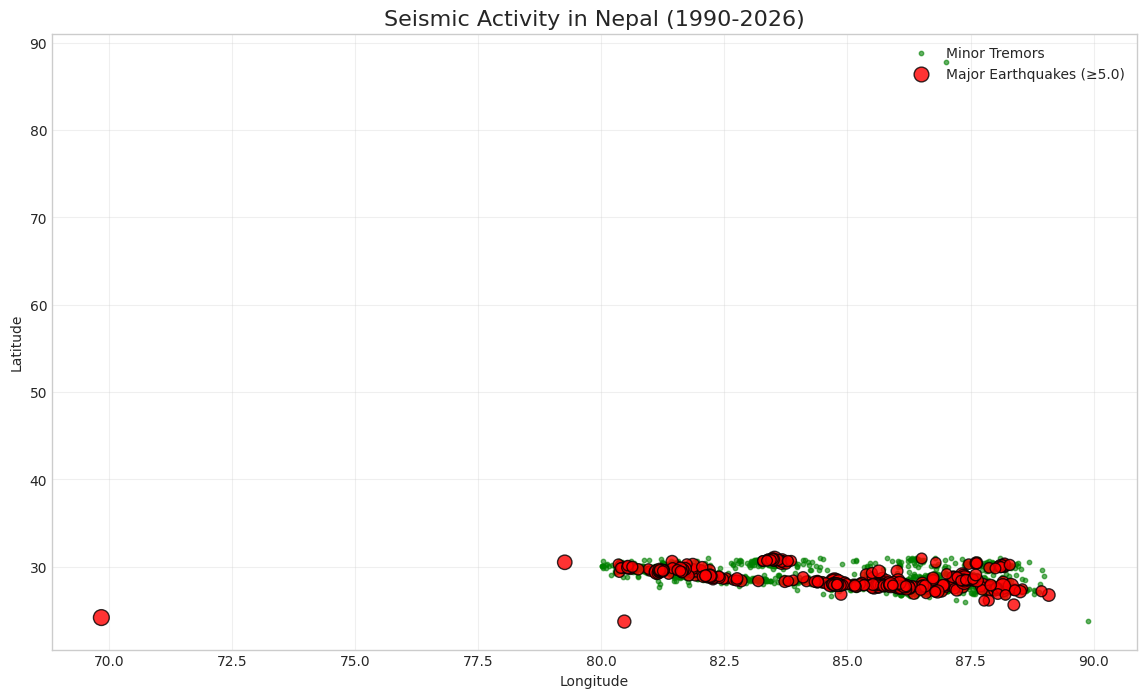

In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

# 1. Plot minor events (Background)
minor = df[df['is_major'] == 0]
ax.scatter(minor['lon'], minor['lat'], 
           alpha=0.6, s=10, c='green', label='Minor Tremors')

# 2. Plot MAJOR events (Foreground)
major = df[df['is_major'] == 1]
scatter = ax.scatter(major['lon'], major['lat'], 
                     alpha=0.8, s=major['mag']**2.5,  # Size relative to magnitude
                     c='red', edgecolors='k', label='Major Earthquakes (≥5.0)')

# Styling
ax.set_title('Seismic Activity in Nepal (1990-2026)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

In [5]:
features = [
    'depth_log',            # Log-transformed depth
    'rolling_count_7d',     # Activity in last 7 days
    'rolling_mean_mag_30d', # Avg magnitude in last 30 days
    'days_since_last_major',# Time since last big event
    'lat_offset', 'lon_offset'
]
target = 'is_major' # is the earthquake major (1) or minor (0)

In [6]:
cutoff_date = '2024-01-01'

train = df[df['dt'] < cutoff_date].copy()
test = df[df['dt'] >= cutoff_date].copy()

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Training on {len(X_train)} historical events (Pre-2024)")
print(f"Testing on  {len(X_test)} recent events (2024-2026)")

Training on 2543 historical events (Pre-2024)
Testing on  190 recent events (2024-2026)


In [9]:
model = LogisticRegression(random_state=42, max_iter=1000)

# Handle missing values before training
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Optional: Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

print("--- Model Performance on Recent Data (2024-2026) ---\n")
print(classification_report(y_test, y_pred, target_names=['Minor', 'Major']))

--- Model Performance on Recent Data (2024-2026) ---

              precision    recall  f1-score   support

       Minor       0.88      1.00      0.94       167
       Major       0.00      0.00      0.00        23

    accuracy                           0.88       190
   macro avg       0.44      0.50      0.47       190
weighted avg       0.77      0.88      0.82       190



/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


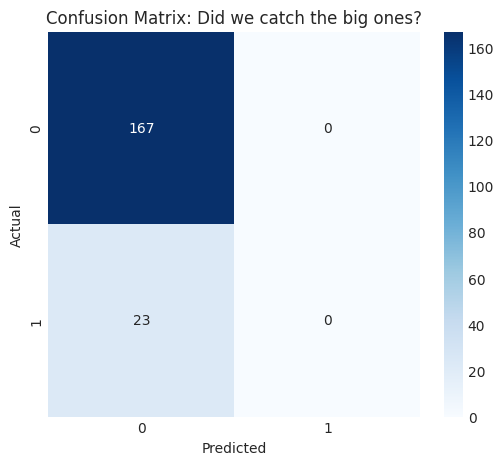

In [10]:
# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Did we catch the big ones?')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()